In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/P2_Estatística_grupo/Analise Exploratoria/absenteeism_tratado.csv' )

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   ID                               706 non-null    int64  
 1   Reason_for_absence               706 non-null    int64  
 2   Month_of_absence                 706 non-null    int64  
 3   Day_of_the_week                  706 non-null    int64  
 4   Seasons                          706 non-null    int64  
 5   Transportation_expense           706 non-null    float64
 6   Distance_from_Residence_to_Work  706 non-null    float64
 7   Service_time                     706 non-null    float64
 8   Age                              706 non-null    float64
 9   Work_load_Average_day            706 non-null    float64
 10  Hit_target                       706 non-null    float64
 11  Disciplinary_failure             706 non-null    int64  
 12  Education             

In [5]:
df.head()

,ID,Reason_for_absence,Month_of_absence,Day_of_the_week,Seasons,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,...,Disciplinary_failure,Education,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,Absenteeism_time_in_hours
0,11,26,7,3,1,289.0,36.0,13.0,33.0,239554.0,...,0,1,2.0,1,0,1.0,90.0,172.0,30.0,4.0
1,36,0,7,3,1,118.0,13.0,18.0,50.0,239554.0,...,1,1,1.0,1,0,0.0,98.0,178.0,31.0,0.0
2,3,23,7,4,1,179.0,51.0,18.0,38.0,239554.0,...,0,1,0.0,1,0,0.0,89.0,170.0,31.0,2.0
3,7,7,7,5,1,279.0,5.0,14.0,39.0,239554.0,...,0,1,2.0,1,1,0.0,68.0,168.0,24.0,4.0
4,11,23,7,5,1,289.0,36.0,13.0,33.0,239554.0,...,0,1,2.0,1,0,1.0,90.0,172.0,30.0,2.0


## Passo 1: Preparação dos Dados (Feature Engineering)

In [7]:
colunas_binarias = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']
df[colunas_binarias] = df[colunas_binarias].astype(int)

In [9]:
# Aplicando One-Hot Encoding para Seasons e Day_of_the_week
# O argumento drop_first=True evita o problema da armadilha da multicolinearidade na regressão
df_modelagem = pd.get_dummies(df, columns=['Seasons', 'Day_of_the_week'], drop_first=True, dtype=int)

#### Agrupando esses 28 códigos de motivos em macro-categorias. Isso ajuda muito a reduzir o ruído nos modelos matemáticos e melhora a interpretabilidade dos coeficientes na regressão.

In [18]:
# 1. Garantir que a coluna está no formato correto (remover pontos flutuantes)
df['Reason_for_absence'] = df['Reason_for_absence'].astype(float).astype(int)

# 2. Criar a função de agrupamento baseada nos motivos
def agrupar_motivos(codigo):
    if codigo == 0:
        return 'punicao_disciplinar'
    elif codigo in [7, 11, 12, 25, 26, 27]:
        return 'consultas_rotina'
    elif codigo in [14, 15, 16, 17, 19, 20]:
        return 'acidentes_lesoes_gestacao'
    else:
        return 'doencas_sintomas_clinicos'

# 3. Aplicar o agrupamento em uma nova coluna
df['Reason_Group'] = df['Reason_for_absence'].apply(agrupar_motivos)

# 4. Forçar as variáveis binárias para o tipo inteiro (0 ou 1)
colunas_binarias = ['Disciplinary_failure', 'Social_drinker', 'Social_smoker']
df[colunas_binarias] = df[colunas_binarias].astype(int)

# 5. Aplicar o One-Hot Encoding nas categóricas
df_modelagem = pd.get_dummies(
    df,
    columns=['Reason_Group', 'Seasons', 'Day_of_the_week'],
    drop_first=True,
    dtype=int
)

# Visualizar o resultado do DataFrame preparado
df_modelagem.head()

,ID,Reason_for_absence,Month_of_absence,Transportation_expense,Distance_from_Residence_to_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,...,Reason_Group_consultas_rotina,Reason_Group_doencas_sintomas_clinicos,Reason_Group_punicao_disciplinar,Seasons_2,Seasons_3,Seasons_4,Day_of_the_week_3,Day_of_the_week_4,Day_of_the_week_5,Day_of_the_week_6
0,11,26,7,289.0,36.0,13.0,33.0,239554.0,97.0,0,...,1,0,0,0,0,0,1,0,0,0
1,36,0,7,118.0,13.0,18.0,50.0,239554.0,97.0,1,...,0,0,1,0,0,0,1,0,0,0
2,3,23,7,179.0,51.0,18.0,38.0,239554.0,97.0,0,...,0,1,0,0,0,0,0,1,0,0
3,7,7,7,279.0,5.0,14.0,39.0,239554.0,97.0,0,...,1,0,0,0,0,0,0,0,1,0
4,11,23,7,289.0,36.0,13.0,33.0,239554.0,97.0,0,...,0,1,0,0,0,0,0,0,1,0


## Passo 2: Contemplando a Parte 5: Análise Bivariada e Multivariada

#### Associação e Correlação (Métricas Lineares)

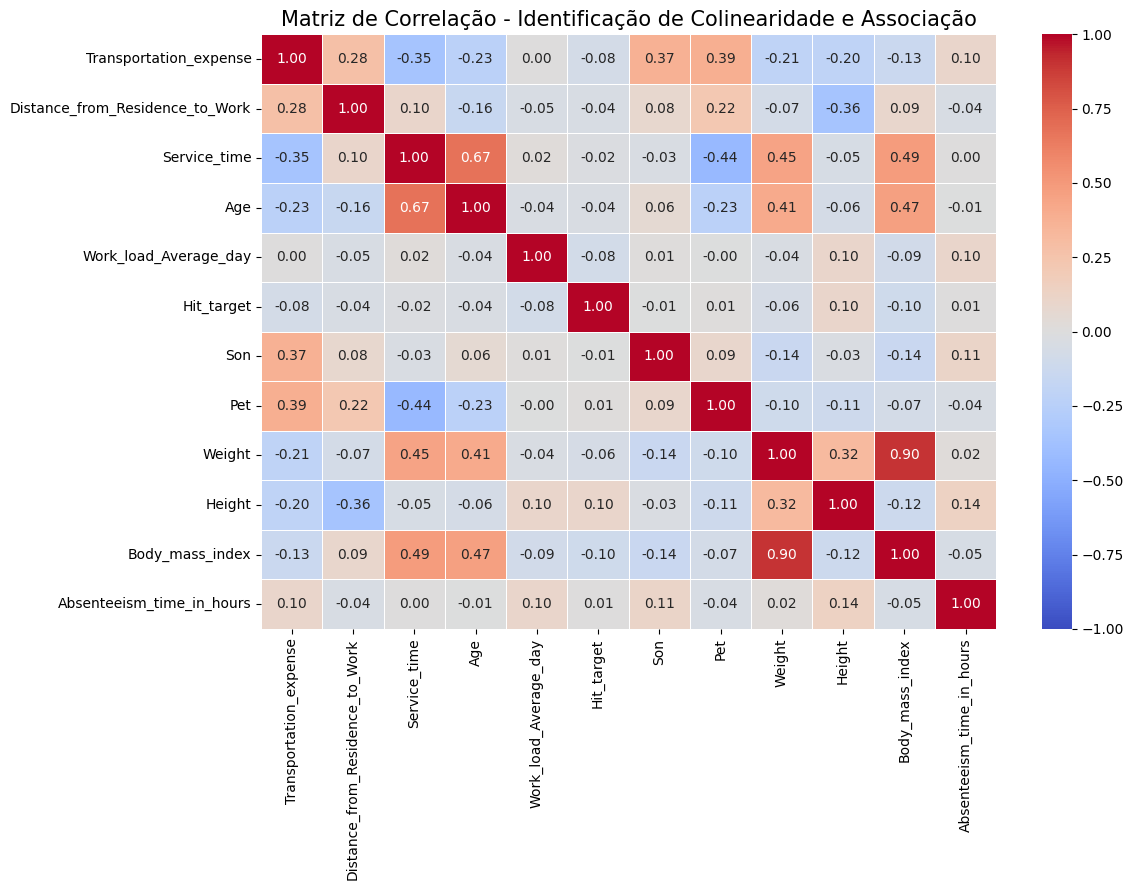


--- Correlação das variáveis com o Tempo de Absenteísmo ---
Absenteeism_time_in_hours          1.000000
Height                             0.136367
Son                                0.110956
Work_load_Average_day              0.098001
Transportation_expense             0.095533
Weight                             0.017154
Hit_target                         0.005800
Service_time                       0.000186
Age                               -0.007502
Distance_from_Residence_to_Work   -0.040956
Pet                               -0.044362
Body_mass_index                   -0.048071
Name: Absenteeism_time_in_hours, dtype: float64


In [19]:
# 1. Definir a lista de variáveis numéricas contínuas e discretas
vars_numericas = [
    'Transportation_expense', 'Distance_from_Residence_to_Work', 'Service_time',
    'Age', 'Work_load_Average_day', 'Hit_target', 'Son', 'Pet',
    'Weight', 'Height', 'Body_mass_index', 'Absenteeism_time_in_hours'
]

# 2. Calcular a matriz de correlação de Pearson
matriz_corr = df_modelagem[vars_numericas].corr()

# 3. Plotar o Heatmap para análise visual no seu ambiente
plt.figure(figsize=(12, 9))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação - Identificação de Colinearidade e Associação', fontsize=15)
plt.tight_layout()
plt.show()

# 4. Exibir as correlações diretas com a nossa variável-alvo (ordenadas)
print("\n--- Correlação das variáveis com o Tempo de Absenteísmo ---")
print(matriz_corr['Absenteeism_time_in_hours'].sort_values(ascending=False))

#### Cruzamento de Categorias (Tabelas de Contingência e Barras Empilhadas)

--- Tabela de Contingência: Grupo de Motivo vs Faixa de Horas (%) ---


Horas_Bin,Curta (Até 2h),Padrão (2h-4h),Diária (4h-8h),Longa (Mais de 8h)
Reason_Group,,,,
acidentes_lesoes_gestacao,10.77,20.00,43.08,26.15
consultas_rotina,34.38,29.38,28.75,7.50
doencas_sintomas_clinicos,36.76,23.29,32.19,7.76
punicao_disciplinar,100.00,0.00,0.00,0.00



--- Tabela de Contingência: Estação do Ano vs Faixa de Horas (%) ---


Horas_Bin,Curta (Até 2h),Padrão (2h-4h),Diária (4h-8h),Longa (Mais de 8h)
Seasons,,,,
1,32.93,25.15,34.73,7.19
2,41.62,21.39,28.90,8.09
3,34.46,22.03,31.07,12.43
4,41.27,23.28,27.51,7.94


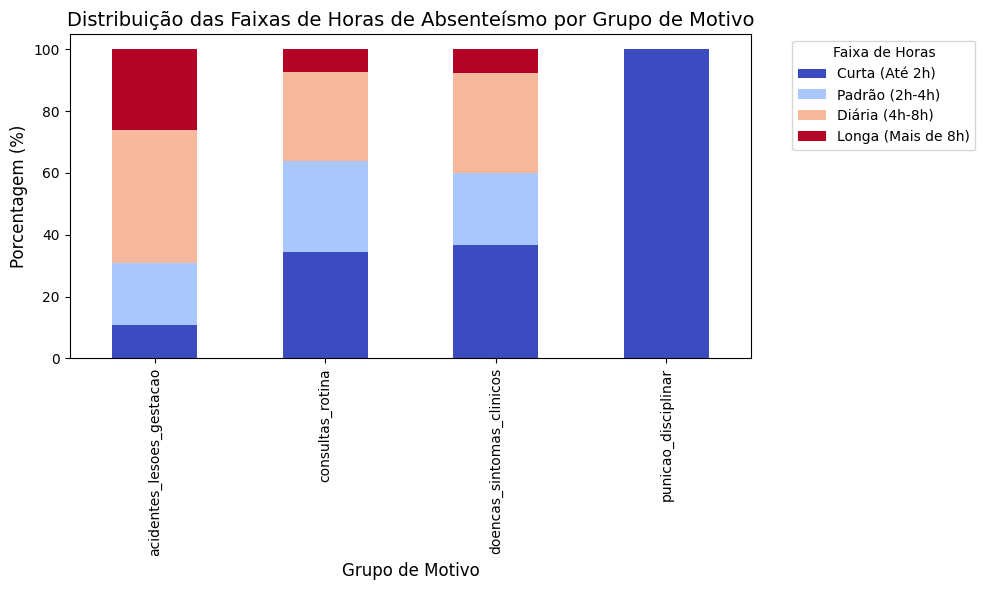

In [23]:
# 1. Criar faixas para a variável-alvo de horas (conforme o comportamento do Boxplot da P1)
df_modelagem['Horas_Bin'] = pd.cut(
    df_modelagem['Absenteeism_time_in_hours'],
    bins=[-np.inf, 2, 4, 8, np.inf],
    labels=['Curta (Até 2h)', 'Padrão (2h-4h)', 'Diária (4h-8h)', 'Longa (Mais de 8h)']
)

# 2. Tabela de Contingência: Cruzamento de Grupo de Motivos com Faixas de Horas
# O normalize='index' converte para porcentagem por linha, facilitando a comparação
print("--- Tabela de Contingência: Grupo de Motivo vs Faixa de Horas (%) ---")
tabela_motivo = pd.crosstab(df['Reason_Group'], df_modelagem['Horas_Bin'], normalize='index') * 100
display(tabela_motivo.round(2))

# 3. Tabela de Contingência: Cruzamento de Estação do Ano com Faixas de Horas
print("\n--- Tabela de Contingência: Estação do Ano vs Faixa de Horas (%) ---")
# Usando o df_tratado original apenas para resgatar os nomes/códigos limpos de Seasons
tabela_estacao = pd.crosstab(df['Seasons'], df_modelagem['Horas_Bin'], normalize='index') * 100
display(tabela_estacao.round(2))

# 4. Gráfico de Barras Empilhadas para Visualização do Cruzamento
tabela_motivo.plot(kind='bar', stacked=True, figsize=(10, 6), cmap='coolwarm')
plt.title('Distribuição das Faixas de Horas de Absenteísmo por Grupo de Motivo', fontsize=14)
plt.xlabel('Grupo de Motivo', fontsize=12)
plt.ylabel('Porcentagem (%)', fontsize=12)
plt.legend(title='Faixa de Horas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Código para aplicar a ACP (PCA)

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Selecionar as variáveis numéricas sem as redundâncias de peso e altura
vars_para_pca = [
    'Transportation_expense', 'Distance_from_Residence_to_Work', 'Service_time',
    'Age', 'Work_load_Average_day', 'Hit_target', 'Son', 'Pet', 'Body_mass_index'
]

# 2. Normalizar os dados (Média = 0, Variância = 1) - Passo crucial para ACP!
scaler = StandardScaler()
dados_normalizados = scaler.fit_transform(df_modelagem[vars_para_pca])

# 3. Instanciar e aplicar o PCA para reduzir para 2 componentes principais
pca = PCA(n_components=2, random_state=42)
componentes_principais = pca.fit_transform(dados_normalizados)

# 4. Criar um DataFrame com os resultados dos componentes para visualização
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
df_pca['Absenteeism_time_in_hours'] = df_modelagem['Absenteeism_time_in_hours'].values

# 5. Verificar quanta informação (variância) esses dois componentes conseguiram reter
variancia_explicada = pca.explained_variance_ratio_
print(f"Variância explicada pelo Componente 1 (PC1): {variancia_explicada[0]*100:.2f}%")
print(f"Variância explicada pelo Componente 2 (PC2): {variancia_explicada[1]*100:.2f}%")
print(f"Variância total retida por ambos: {sum(variancia_explicada)*100:.2f}%\n")

# 6. Exibir a carga (loadings) de cada variável original nos componentes
df_loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=vars_para_pca
)
print("--- Peso (Influência) de cada variável nos Componentes ---")
display(df_loadings.round(3))

Variância explicada pelo Componente 1 (PC1): 27.88%
Variância explicada pelo Componente 2 (PC2): 16.41%
Variância total retida por ambos: 44.30%

--- Peso (Influência) de cada variável nos Componentes ---


,PC1,PC2
Transportation_expense,-0.390,0.447
Distance_from_Residence_to_Work,-0.126,0.514
Service_time,0.535,0.242
Age,0.483,0.254
Work_load_Average_day,-0.024,-0.078
Hit_target,-0.023,-0.211
Son,-0.154,0.385
Pet,-0.374,0.275
Body_mass_index,0.385,0.371


#### Clusterização (K-Means)

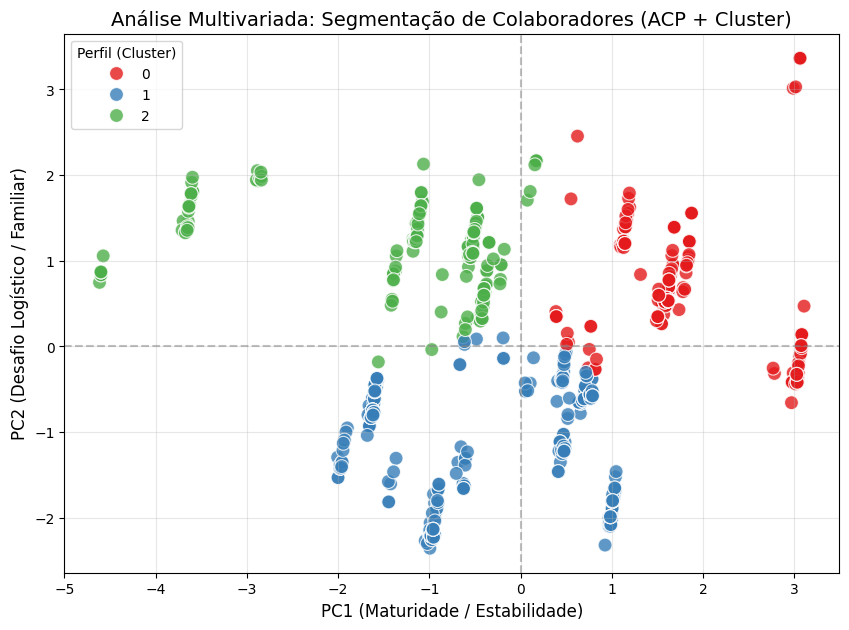

--- Perfil Médio de cada Cluster ---


,Age,Service_time,Distance_from_Residence_to_Work,Transportation_expense,Son,Absenteeism_time_in_hours
Cluster_Perfil,,,,,,
0,42.82,17.11,34.66,189.41,0.69,4.74
1,33.22,10.68,19.76,201.14,0.67,5.49
2,34.97,10.49,39.13,294.95,2.11,6.76


In [25]:
from sklearn.cluster import KMeans

# 1. Usar as coordenadas da ACP (PC1 e PC2) que capturam 44.3% da variância
X_cluster = df_pca[['PC1', 'PC2']]

# 2. Instanciar o K-Means (vamos definir 3 grupos/perfis de colaboradores)
kmeans = KMeans(n_clusters=3, random_state=42)
df_modelagem['Cluster_Perfil'] = kmeans.fit_predict(X_cluster)
df_pca['Cluster_Perfil'] = df_modelagem['Cluster_Perfil'].values

# 3. Plotar o gráfico de dispersão dos perfis encontrados
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Cluster_Perfil',
    palette='Set1',
    data=df_pca,
    s=100, alpha=0.8
)

plt.title('Análise Multivariada: Segmentação de Colaboradores (ACP + Cluster)', fontsize=14)
plt.xlabel('PC1 (Maturidade / Estabilidade)', fontsize=12)
plt.ylabel('PC2 (Desafio Logístico / Familiar)', fontsize=12)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Perfil (Cluster)')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Média das variáveis originais por cluster para entender quem é quem
print("--- Perfil Médio de cada Cluster ---")
vars_originais = ['Age', 'Service_time', 'Distance_from_Residence_to_Work', 'Transportation_expense', 'Son', 'Absenteeism_time_in_hours']
display(df_modelagem.groupby('Cluster_Perfil')[vars_originais].mean().round(2))

## Passo 2: Contemplando a Parte 6: Noção de Modelo de Regressão.  

#### Código para a Regressão Linear e Métricas ($R^2$)

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Selecionar as variáveis preditoras (X) e a variável alvo (y)
# Incluímos as numéricas tratadas e os dummies gerados no Passo 1
features = [
    'Transportation_expense', 'Distance_from_Residence_to_Work', 'Service_time',
    'Age', 'Work_load_Average_day', 'Hit_target', 'Son', 'Pet', 'Body_mass_index',
    'Disciplinary_failure', 'Social_drinker', 'Social_smoker'
]

# Adicionando as colunas dummy criadas (exceto a de punição para evitar colinearidade perfeita)
colunas_dummies = [col for col in df_modelagem.columns if 'Reason_Group_' in col or 'Seasons_' in col or 'Day_of_the_week_' in col]
X_features = features + colunas_dummies

X = df_modelagem[X_features]
y = df_modelagem['Absenteeism_time_in_hours']

# 2. Dividir os dados em Treino (80%) e Teste (20%) para validação cruzada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Treinar o modelo de Regressão Linear
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)

# 4. Realizar as previsões na base de teste e calcular as métricas
y_pred = modelo_regressao.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("--- Métricas de Performance do Modelo ---")
print(f"Coeficiente de Determinação (R²): {r2:.4f} (Indica o quanto o modelo explica a variabilidade)")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} horas\n")

# 5. Extrair e ordenar os coeficientes para interpretação de peso
df_coeficientes = pd.DataFrame({
    'Variável': X_features,
    'Coeficiente (Peso)': modelo_regressao.coef_
})

print("--- Peso (Impacto) de cada Variável na Equação Final ---")
display(df_coeficientes.sort_values(by='Coeficiente (Peso)', ascending=False).round(4))

--- Métricas de Performance do Modelo ---
Coeficiente de Determinação (R²): 0.0644 (Indica o quanto o modelo explica a variabilidade)
Erro Médio Absoluto (MAE): 4.00 horas

--- Peso (Impacto) de cada Variável na Equação Final ---


,Variável,Coeficiente (Peso)
10,Social_drinker,2.5263
6,Son,0.2898
17,Seasons_4,0.2512
16,Seasons_3,0.0313
2,Service_time,0.0188
0,Transportation_expense,0.0097
3,Age,0.0070
4,Work_load_Average_day,0.0000
5,Hit_target,-0.0461
1,Distance_from_Residence_to_Work,-0.0606


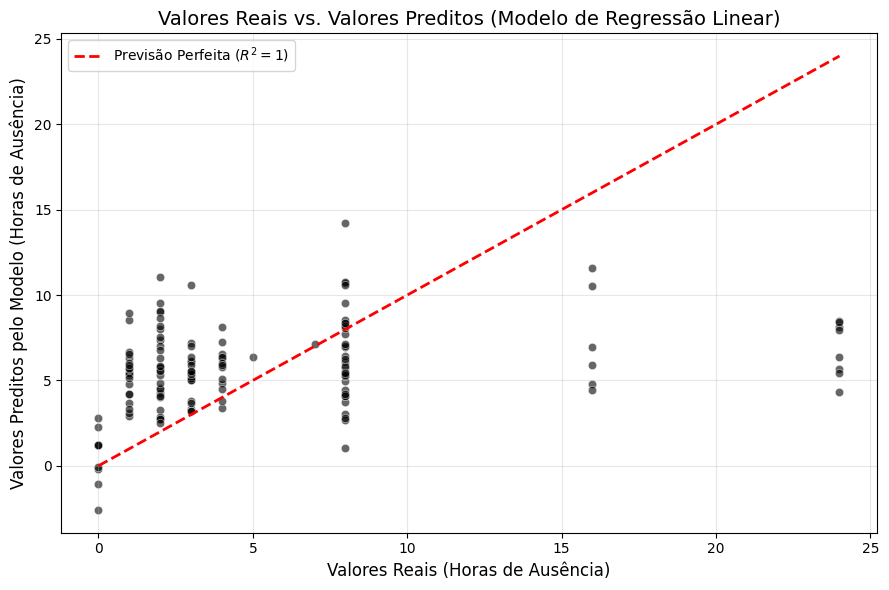

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar o tamanho do gráfico
plt.figure(figsize=(9, 6))

# 2. Criar o gráfico de dispersão: Valores Reais vs. Valores Preditos
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='black')

# 3. Criar a linha diagonal de referência (Previsão Perfeita)
# Ela vai do valor mínimo ao valor máximo dos dados reais
valores_reais = [y_test.min(), y_test.max()]
plt.plot(valores_reais, valores_reais, color='red', linestyle='--', linewidth=2, label='Previsão Perfeita ($R^2 = 1$)')

# 4. Adicionar títulos e rótulos aos eixos
plt.title('Valores Reais vs. Valores Preditos (Modelo de Regressão Linear)', fontsize=14)
plt.xlabel('Valores Reais (Horas de Ausência)', fontsize=12)
plt.ylabel('Valores Preditos pelo Modelo (Horas de Ausência)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 5. Exibir o gráfico
plt.tight_layout()
plt.show()